#Oil Spill Segmentation - Data Preprocessing & Augmentation

# Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Imports & Config

In [ ]:
import tensorflow as tf
import os
from glob import glob
from tensorflow.keras.utils import img_to_array, load_img
from tensorflow.keras import layers, Model, backend as K
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [ ]:
# Config
IMG_SIZE = (256, 256)
BATCH_SIZE = 8
AUTOTUNE = tf.data.AUTOTUNE

# Paths
base_dir = "/content/drive/MyDrive/oil_spill_dataset"
train_img_dir  = os.path.join(base_dir, "train/images")
train_mask_dir = os.path.join(base_dir, "train/masks")
val_img_dir    = os.path.join(base_dir, "val/images")
val_mask_dir   = os.path.join(base_dir, "val/masks")

# Helper Functions

In [ ]:
def augment_image_mask(image, mask):
    """ Apply random augmentations to image and mask.
    1.horizontal flip
    2.vertical flip
    3.90° rotation
    4.zoom (central crop + resize)
    5.saturation
    6.contrast
    7.brightness """

    # Ensure dtype consistency
    image = tf.cast(image, tf.float32)
    mask  = tf.cast(mask, tf.float32)

    # Random horizontal flip
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask  = tf.image.flip_left_right(mask)

    # Random vertical flip
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask  = tf.image.flip_up_down(mask)

    # Random 90° rotation
    k = tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    mask  = tf.image.rot90(mask, k)

    # Random zoom (central crop + resize)
    if tf.random.uniform(()) > 0.5:
        scale = tf.random.uniform([], 0.8, 1.0)
        crop_size = tf.cast(scale * tf.cast(tf.shape(image)[0], tf.float32), tf.int32)

        image = tf.image.resize_with_crop_or_pad(image, crop_size, crop_size)
        mask  = tf.image.resize_with_crop_or_pad(mask, crop_size, crop_size)

        image = tf.image.resize(image, IMG_SIZE)
        mask  = tf.image.resize(mask, IMG_SIZE, method="nearest")

    # Image-only color jitter
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    image = tf.image.random_saturation(image, 0.9, 1.1)

    return image, mask




In [ ]:
def median_filter(image, ksize=3):
    # image: [H, W, C], float32 [0,1]
    image = tf.expand_dims(image, axis=0)  # [1, H, W, C]

    patches = tf.image.extract_patches(
        images=image,
        sizes=[1, ksize, ksize, 1],
        strides=[1, 1, 1, 1],
        rates=[1, 1, 1, 1],
        padding="SAME"
    )  # [1, H, W, ksize*ksize*C]

    H = tf.shape(image)[1]
    W = tf.shape(image)[2]
    C = tf.shape(image)[3]

    # Reshape so each channel is separate: [H, W, C, ksize*ksize]
    patches = tf.reshape(patches, [1, H, W, ksize*ksize, C])

    # Take median along window dimension
    patches = tf.sort(patches, axis=3)  # sort along patch axis
    med = patches[:, :, :, ksize*ksize//2, :]  # pick median

    med_img = tf.squeeze(med, axis=0)  # [H, W, C]

    return med_img


In [ ]:
def normalize_image_mask(image, mask):
    """Resize and normalize image; resize mask with nearest neighbor."""
    image = tf.cast(image, tf.float32)
    mask  = tf.cast(mask, tf.float32)

    # Resize
    image = tf.image.resize(image, IMG_SIZE)
    mask  = tf.image.resize(mask, IMG_SIZE, method="nearest")

    # Normalize image
    image = image / 255.0

    # Apply median filter
    #image = median_filter(image, ksize=3)

    # Binarize mask
    mask = mask / 255.0
    mask = tf.where(mask > 0.5, 1.0, 0.0)

    return image, mask


In [ ]:
def load_and_preprocess(img_path, mask_path, training=False):
    """Load, decode, and preprocess a single image-mask pair."""
    # Read image
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)

    # Read mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)

    # Augment only during training
    if training:
        img, mask = augment_image_mask(img, mask)

    img, mask = normalize_image_mask(img, mask)
    return img, mask

In [ ]:
# for visualization
def unnormalize(img):
    return tf.clip_by_value(img, 0.0, 1.0)


# Build Dataset

In [ ]:
# Collect file paths
train_img_paths = sorted(glob(os.path.join(train_img_dir, "*.jpg")))
train_mask_paths = sorted(glob(os.path.join(train_mask_dir, "*.png")))
val_img_paths   = sorted(glob(os.path.join(val_img_dir, "*.jpg")))
val_mask_paths  = sorted(glob(os.path.join(val_mask_dir, "*.png")))

print("Train images:", len(train_img_paths))
print("Train masks :", len(train_mask_paths))
print("Val images  :", len(val_img_paths))
print("Val masks   :", len(val_mask_paths))

# Build tf.data pipelines
train_ds = tf.data.Dataset.from_tensor_slices((train_img_paths, train_mask_paths))
val_ds   = tf.data.Dataset.from_tensor_slices((val_img_paths, val_mask_paths))

train_ds = (train_ds
            .map(lambda x,y: load_and_preprocess(x,y,True), num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

val_ds = (val_ds
          .map(lambda x,y: load_and_preprocess(x,y,False), num_parallel_calls=AUTOTUNE)
          .batch(BATCH_SIZE)
          .prefetch(AUTOTUNE))

Train images: 811
Train masks : 811
Val images  : 203
Val masks   : 203


# Visualization

In [ ]:
def visualize_batch(dataset, n=3):
    """Show sample batch of images and masks."""
    for images, masks in dataset.take(1):
        plt.figure(figsize=(12,6))
        for i in range(n):
            plt.subplot(2,n,i+1)
            plt.imshow(unnormalize(images[i]).numpy())
            plt.title("Image")
            plt.axis("off")

            plt.subplot(2,n,n+i+1)
            plt.imshow(masks[i].numpy().squeeze(), cmap="gray")
            plt.title("Mask")
            plt.axis("off")
        plt.show()

def visualize_comparison(img_path, mask_path):
    """Compare raw vs augmented samples."""
    raw_img = tf.image.decode_jpeg(tf.io.read_file(img_path), channels=3)
    raw_mask = tf.image.decode_png(tf.io.read_file(mask_path), channels=1)

    aug_img, aug_mask = augment_image_mask(raw_img, raw_mask)
    aug_img, aug_mask = normalize_image_mask(aug_img, aug_mask)

    plt.figure(figsize=(8,4))
    plt.subplot(2,2,1); plt.imshow(raw_img.numpy().astype("uint8")); plt.title("Raw Image"); plt.axis("off")
    plt.subplot(2,2,2); plt.imshow(raw_mask.numpy().squeeze(), cmap="gray"); plt.title("Raw Mask"); plt.axis("off")
    plt.subplot(2,2,3); plt.imshow(unnormalize(aug_img).numpy()); plt.title("Aug Image"); plt.axis("off")
    plt.subplot(2,2,4); plt.imshow(aug_mask.numpy().squeeze(), cmap="gray"); plt.title("Aug Mask"); plt.axis("off")
    plt.show()


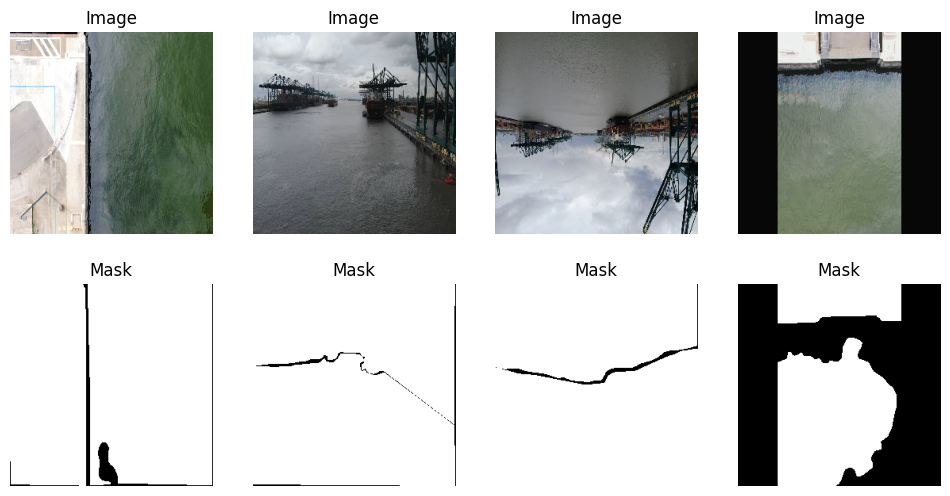

In [ ]:
visualize_batch(train_ds, n=4)

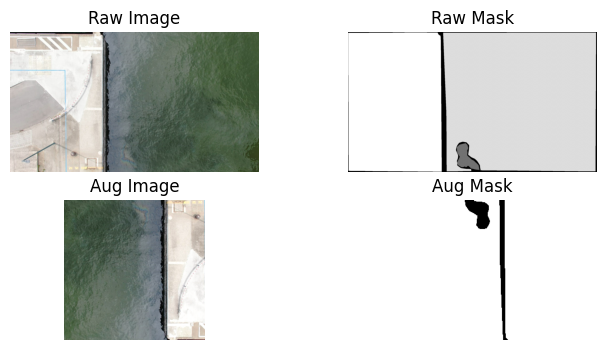

In [ ]:
visualize_comparison(train_img_paths[0], train_mask_paths[0])

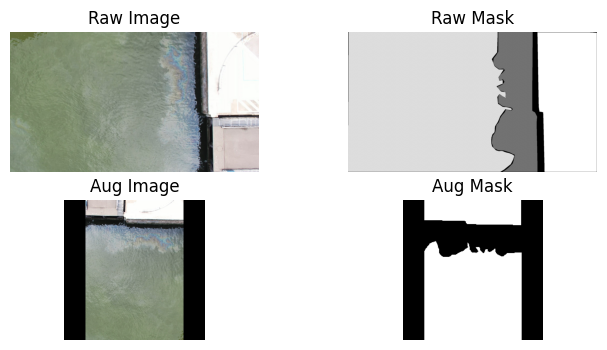

In [ ]:
visualize_comparison(train_img_paths[10], train_mask_paths[10])

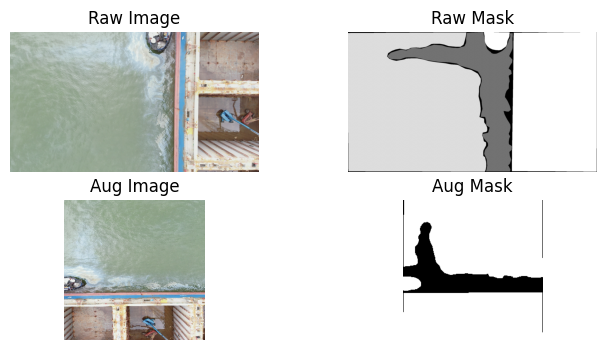

In [ ]:
visualize_comparison(train_img_paths[109], train_mask_paths[109])

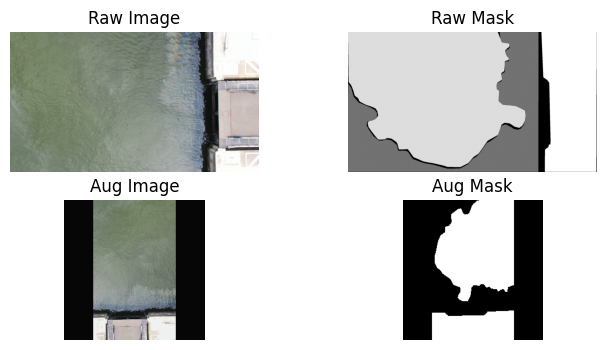

In [ ]:
visualize_comparison(train_img_paths[3], train_mask_paths[3])

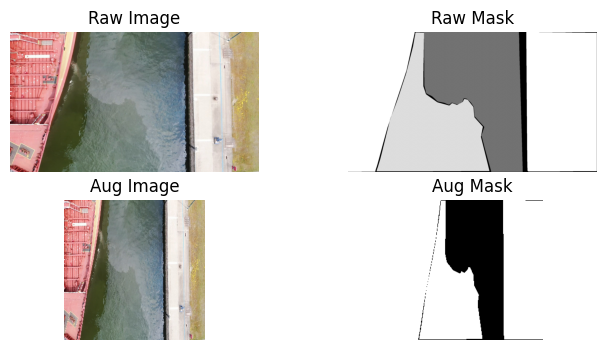

In [ ]:
visualize_comparison(train_img_paths[697], train_mask_paths[697])

In [ ]:
# Check if color jitters have been applied
for img, mask in train_ds.take(1):
    print("Image mean:", tf.reduce_mean(img).numpy())
    print("Image std:", tf.math.reduce_std(img).numpy())

Image mean: 0.53288287
Image std: 0.19683886


# UNET MODEEL #

In [ ]:
# -----------------------------
# Module 3: Model Development
# -----------------------------
def conv_block(x, filters, kernel_size=3, activation="relu", batchnorm=True):
    x = layers.Conv2D(filters, kernel_size, padding="same")(x)
    if batchnorm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)
    x = layers.Conv2D(filters, kernel_size, padding="same")(x)
    if batchnorm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)
    return x

def encoder_block(x, filters):
    c = conv_block(x, filters)
    p = layers.MaxPooling2D((2,2))(c)
    return c, p

def decoder_block(x, skip, filters):
    x = layers.Conv2DTranspose(filters, (2,2), strides=(2,2), padding="same")(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x

def build_unet(input_shape=(256, 256, 3), base_filters=32, dropout=0.1):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1, p1 = encoder_block(inputs, base_filters)
    c2, p2 = encoder_block(p1, base_filters*2)
    c3, p3 = encoder_block(p2, base_filters*4)
    c4, p4 = encoder_block(p3, base_filters*8)

    # Bridge
    b = conv_block(p4, base_filters*16)
    if dropout:
        b = layers.Dropout(dropout)(b)

    # Decoder
    d1 = decoder_block(b, c4, base_filters*8)
    d2 = decoder_block(d1, c3, base_filters*4)
    d3 = decoder_block(d2, c2, base_filters*2)
    d4 = decoder_block(d3, c1, base_filters)

    outputs = layers.Conv2D(1, (1,1), padding="same", activation="sigmoid")(d4)

    model = Model(inputs, outputs, name="U-Net")
    return model

# Build segmentation model
seg_model = build_unet(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), base_filters=32, dropout=0.1)
seg_model.summary()


Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_4[0][0]  

 Total params: 7,771,873 (29.65 MB)

 Trainable params: 7,765,985 (29.62 MB)

 Non-trainable params: 5,888 (23.00 KB)

# LOSSES & METRICS #

In [ ]:
# -----------------------------
# 4.1 Custom Metrics
# -----------------------------
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(tf.cast(y_pred > 0.5, tf.float32))
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def iou_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(tf.cast(y_pred > 0.5, tf.float32))
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def soft_iou(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# -----------------------------
# 4.2 Loss Functions
# -----------------------------
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(tf.cast(y_pred, tf.float32))
    intersection = K.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def weighted_bce(y_true, y_pred, beta=3.0):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    bce = tf.reshape(bce, [-1])  # flatten safely
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    weights = 1 + (beta - 1) * y_true_f
    return K.mean(weights * bce)

def combo_loss(y_true, y_pred, alpha=0.5, beta=3.0):
    """
    alpha = balance between Dice and BCE
    beta = weight for BCE (foreground emphasis)
    """
    return alpha * dice_loss(y_true, y_pred) + (1 - alpha) * weighted_bce(y_true, y_pred, beta=beta)

# --- Precision & Recall ---
precision = tf.keras.metrics.Precision()
recall    = tf.keras.metrics.Recall()

# TRAIN & EVAL #


In [ ]:
# -----------------------------
# 4.3 Compile Model
# -----------------------------

def chosen_loss(y_true, y_pred):
    return combo_loss(y_true, y_pred, alpha=0.5, beta=0.3)

seg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=chosen_loss,
    metrics=[dice_coef, iou_coef, soft_iou, "accuracy"]
)


# -----------------------------
# 4.4 Callbacks & Training
# -----------------------------
CHECKPOINT_PATH = "/content/drive/MyDrive/oil_spill_models/seg_model_best.keras"
os.makedirs(os.path.dirname(CHECKPOINT_PATH), exist_ok=True)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(CHECKPOINT_PATH, monitor="val_loss", save_best_only=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1, min_lr=1e-7),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=12, verbose=1, restore_best_weights=True)
]


In [ ]:
EPOCHS = 50

history = seg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# -----------------------------
# 4.5 Save Final Model
# -----------------------------
seg_model.save("/content/drive/MyDrive/oil_spill_models/seg_model_final.keras")


Epoch 1/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7841 - dice_coef: 0.7852 - iou_coef: 0.6795 - loss: 0.2692 - soft_iou: 0.5961   
Epoch 1: val_loss improved from inf to 0.31528, saving model to /content/drive/MyDrive/oil_spill_models/seg_model_best.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.7844 - dice_coef: 0.7854 - iou_coef: 0.6798 - loss: 0.2690 - soft_iou: 0.5963 - val_accuracy: 0.7782 - val_dice_coef: 0.8081 - val_iou_coef: 0.7155 - val_loss: 0.3153 - val_soft_iou: 0.6757 - learning_rate: 1.0000e-04
Epoch 2/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7695 - dice_coef: 0.7734 - iou_coef: 0.6598 - loss: 0.2818 - soft_iou: 0.5817
Epoch 2: val_loss did not improve from 0.31528
102/102 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.7699 - dice_coef: 0.7736 - iou_coef: 0.6601 - loss: 0.2816 - soft_iou: 0.5820 - val_accuracy: 0.7863 - val_dice_coef: 0.8129 - val_iou_coef: 0.7216 - val_loss: 0.3206 - val_soft_iou: 0.6731 - learning_rate: 1.

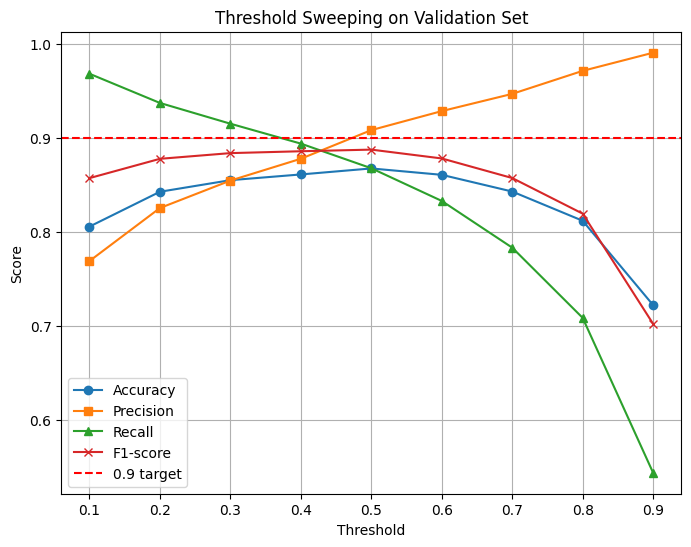

Best threshold: 0.50
Accuracy: 0.8674, Precision: 0.9081, Recall: 0.8676, F1: 0.8874


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load best model so far
from tensorflow.keras.models import load_model

seg_model = load_model(
    "/content/drive/MyDrive/oil_spill_models/seg_model_best.keras",
    compile=False  # compile not needed for inference
)

# ---------------------------
# 1. Get ground truth + predictions on validation set
# ---------------------------
y_true_all = []
y_pred_all = []

for images, masks in val_ds:   # val_ds = your validation tf.data dataset
    preds = seg_model.predict(images, verbose=0)
    y_true_all.append(masks.numpy())
    y_pred_all.append(preds)

y_true_all = np.concatenate(y_true_all, axis=0)
y_pred_all = np.concatenate(y_pred_all, axis=0)

# Flatten for metrics (pixel-level)
y_true_flat = y_true_all.flatten()

# ---------------------------
# 2. Sweep thresholds
# ---------------------------
thresholds = np.linspace(0.1, 0.9, 9)   # 0.1, 0.2, ... 0.9
accs, precs, recs, f1s = [], [], [], []

for t in thresholds:
    y_pred_bin = (y_pred_all > t).astype(np.uint8).flatten()
    accs.append(accuracy_score(y_true_flat, y_pred_bin))
    precs.append(precision_score(y_true_flat, y_pred_bin, zero_division=0))
    recs.append(recall_score(y_true_flat, y_pred_bin, zero_division=0))
    f1s.append(f1_score(y_true_flat, y_pred_bin, zero_division=0))

# ---------------------------
# 3. Plot curves
# ---------------------------
plt.figure(figsize=(8,6))
plt.plot(thresholds, accs, marker='o', label="Accuracy")
plt.plot(thresholds, precs, marker='s', label="Precision")
plt.plot(thresholds, recs, marker='^', label="Recall")
plt.plot(thresholds, f1s, marker='x', label="F1-score")
plt.axhline(0.9, color='r', linestyle='--', label="0.9 target")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Sweeping on Validation Set")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------
# 4. Print best threshold
# ---------------------------
best_idx = np.argmax(accs)
print(f"Best threshold: {thresholds[best_idx]:.2f}")
print(f"Accuracy: {accs[best_idx]:.4f}, Precision: {precs[best_idx]:.4f}, Recall: {recs[best_idx]:.4f}, F1: {f1s[best_idx]:.4f}")

# Visualization

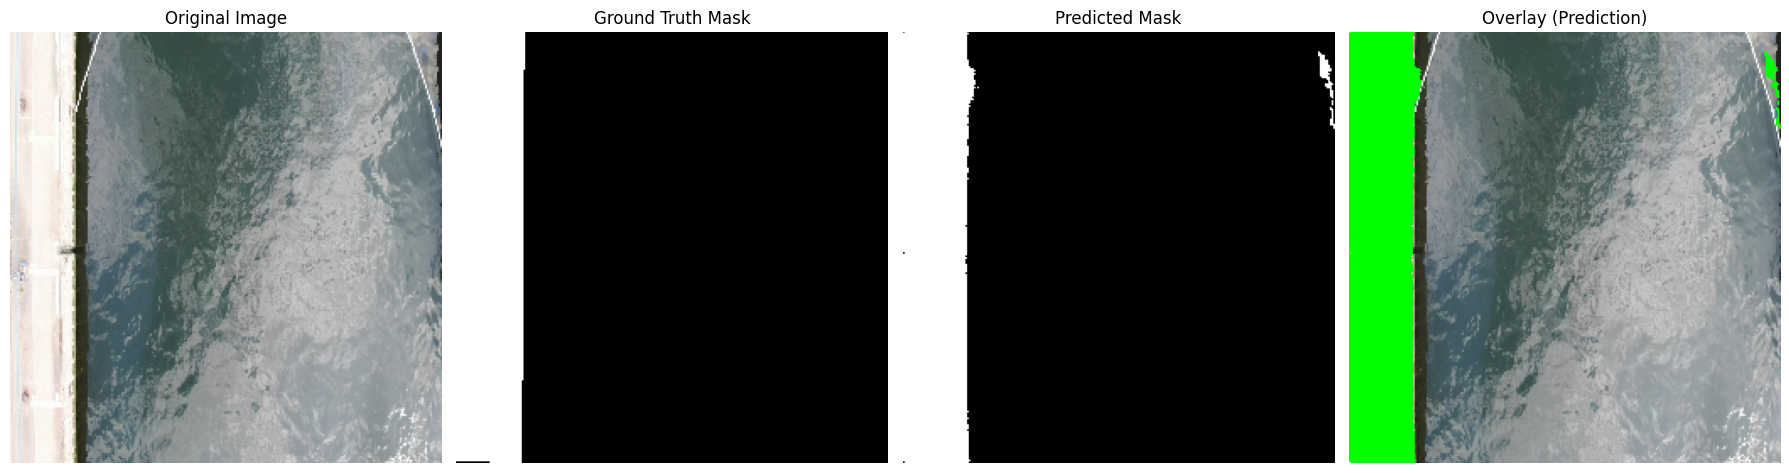

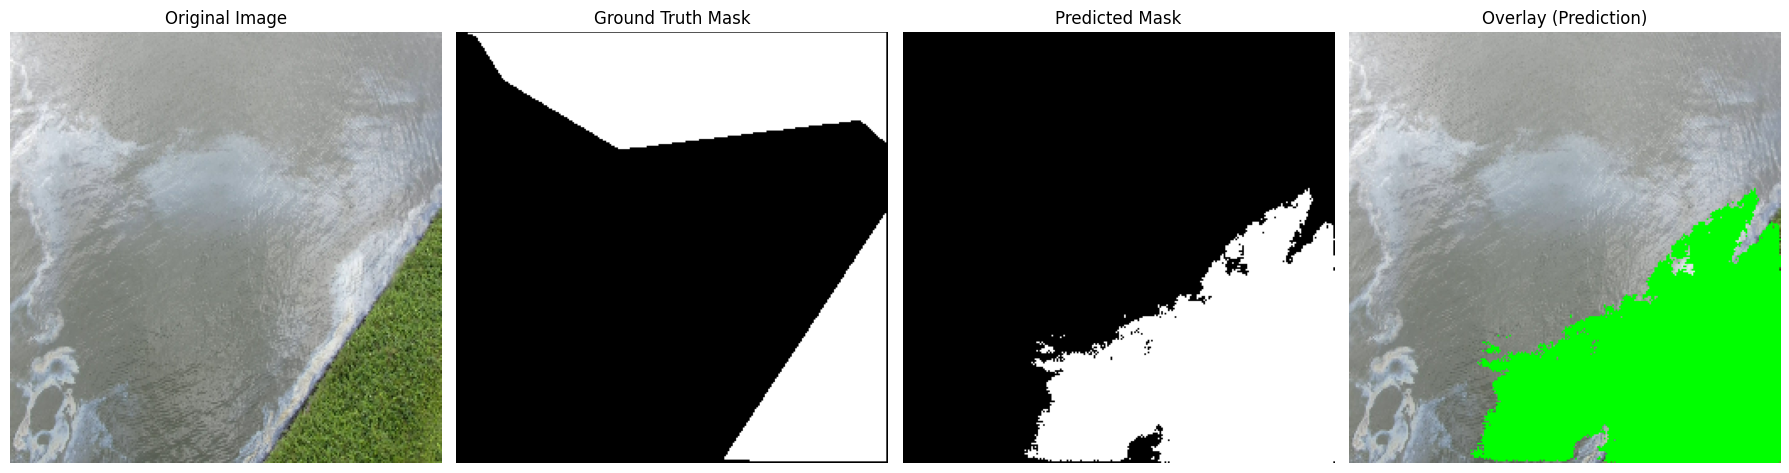

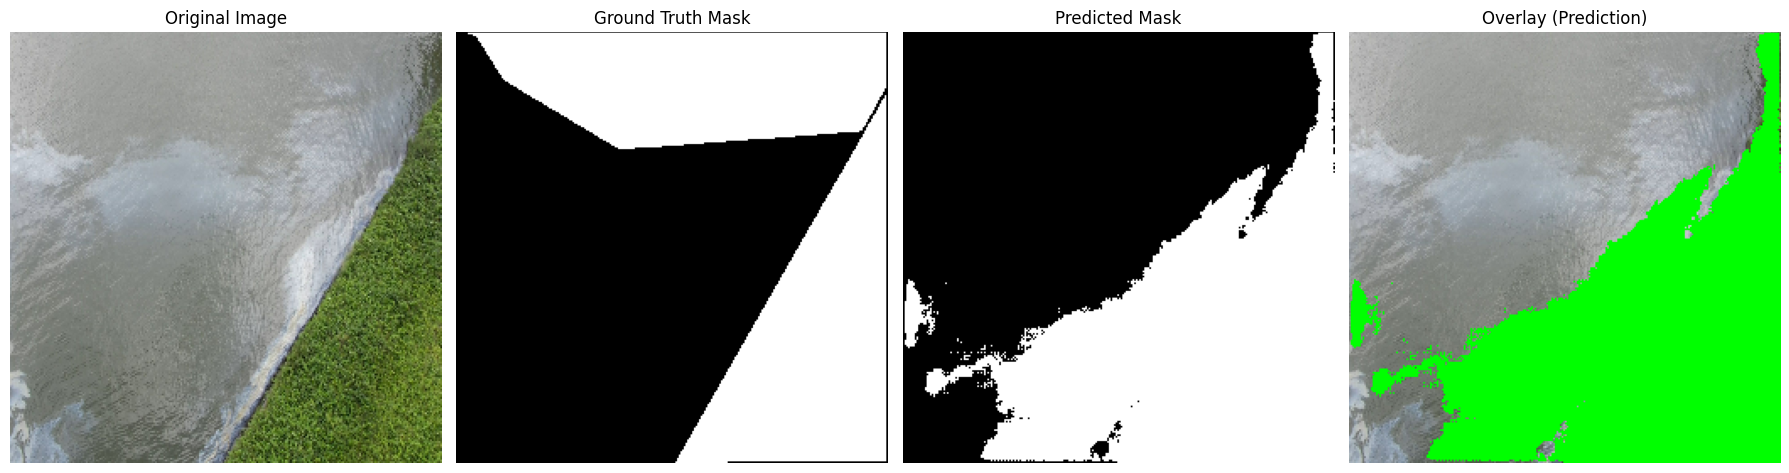

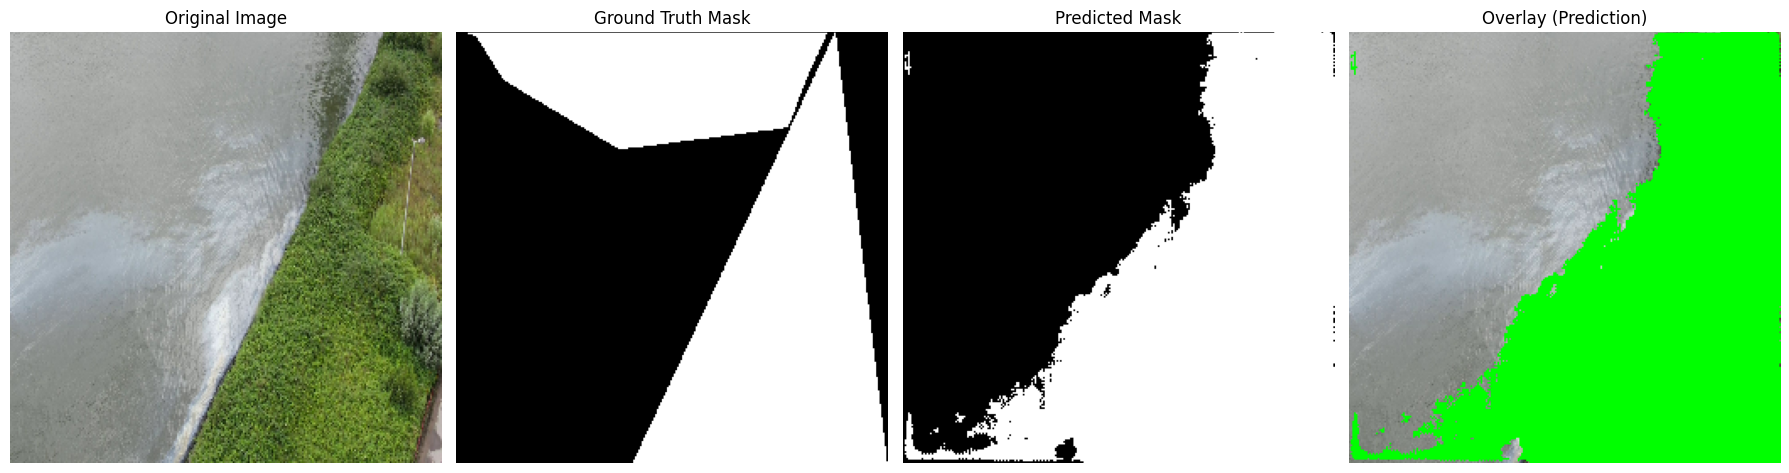

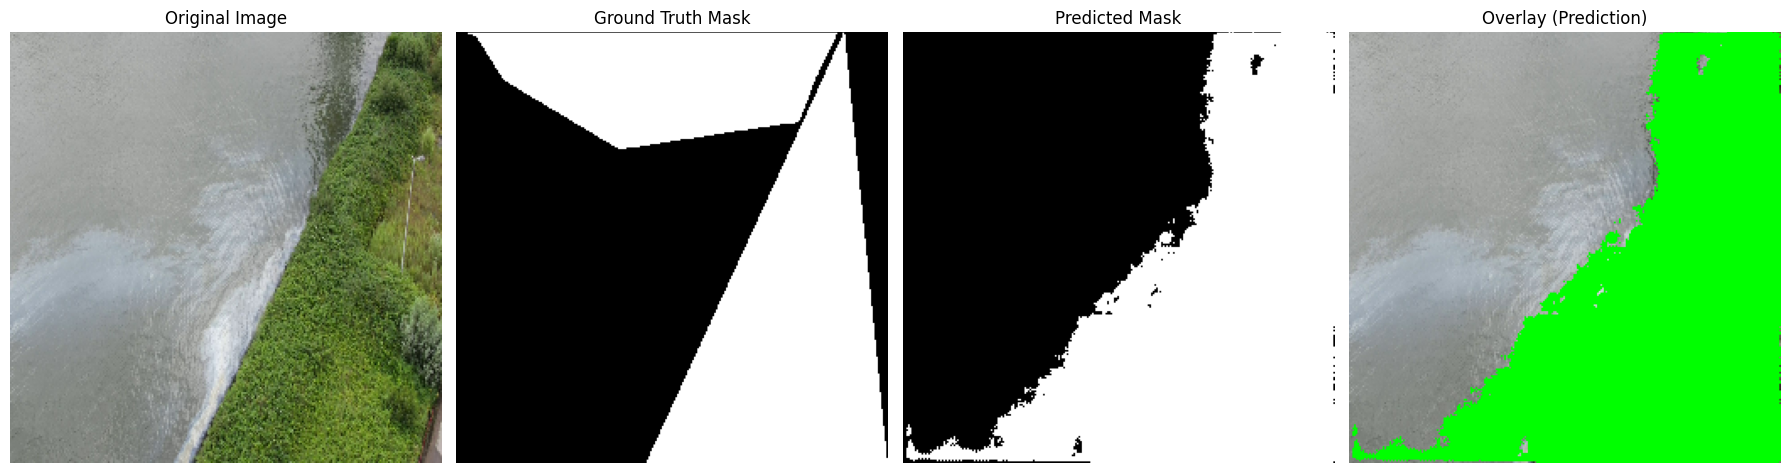

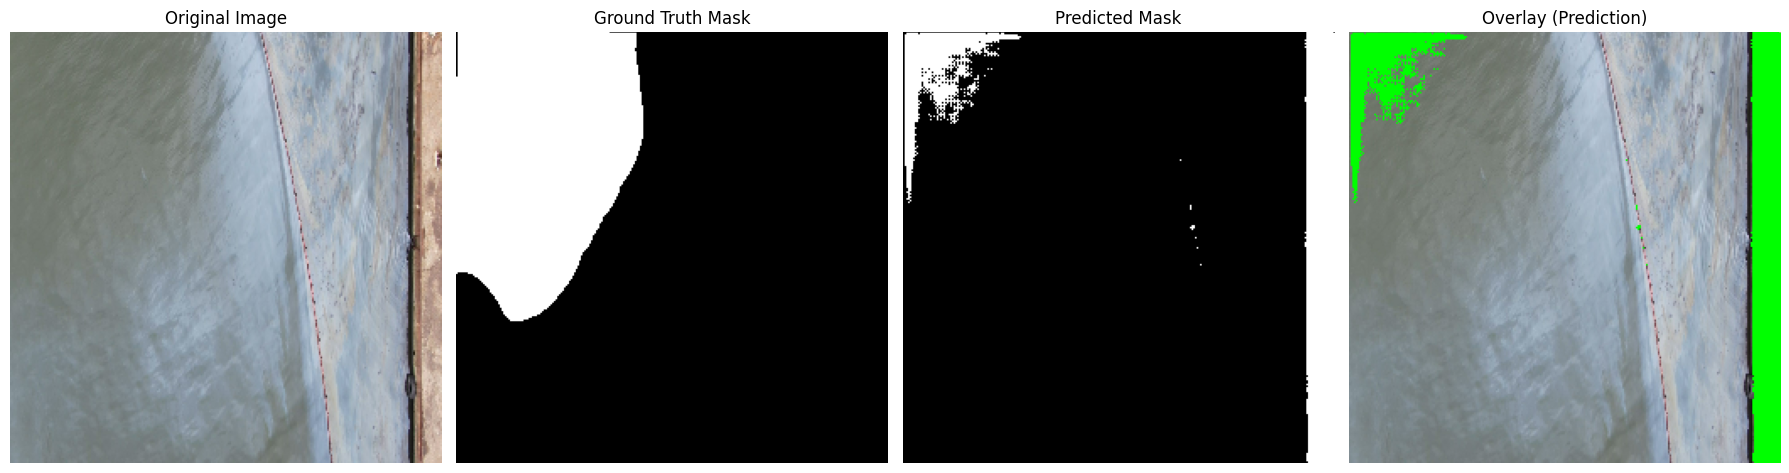

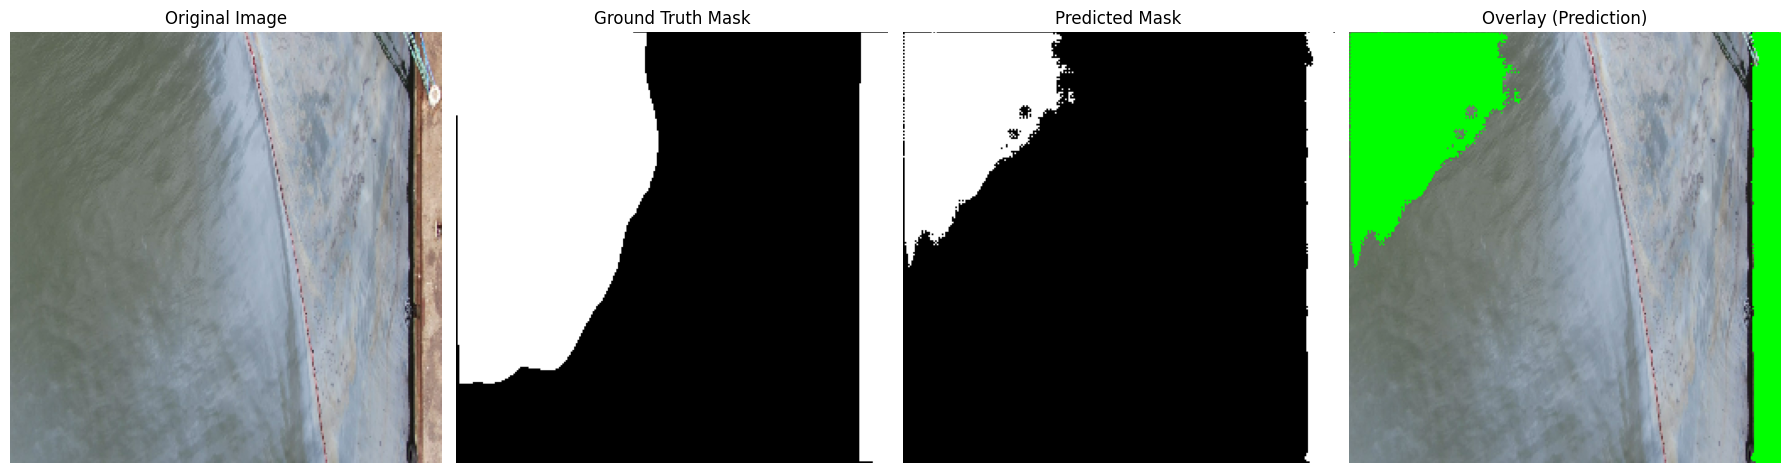

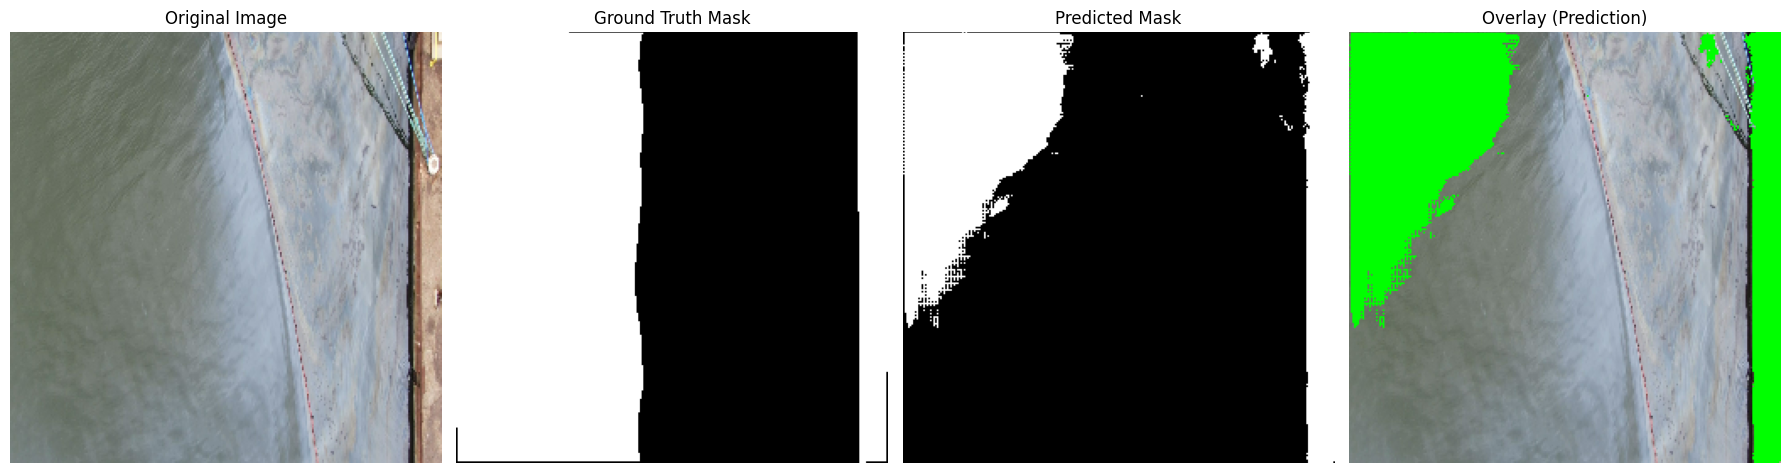

In [ ]:
# Load best model
best_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/oil_spill_models/seg_model_best.keras",
    compile=False
)


num_samples = 1
sample_batches = list(val_ds.skip(2).take(1))


def display_results(model, sample_batches, threshold=0.6):
    for images, masks in sample_batches:
        preds = model.predict(images, verbose=0)
        preds_bin = (preds > threshold).astype(np.uint8)

        for i in range(len(images)):
            img   = images[i].numpy()
            gt    = masks[i].numpy().squeeze()
            pred  = preds_bin[i].squeeze()

            # Overlay mask on image
            overlay_gt   = img.copy()
            overlay_pred = img.copy()

            # Red overlay for ground truth
            overlay_gt[gt == 1] = [1.0, 0.0, 0.0]
            # Green overlay for prediction
            overlay_pred[pred == 1] = [0.0, 1.0, 0.0]

            fig, axs = plt.subplots(1, 4, figsize=(18, 5))

            axs[0].imshow(img)
            axs[0].set_title("Original Image")
            axs[0].axis("off")

            axs[1].imshow(gt, cmap="gray")
            axs[1].set_title("Ground Truth Mask")
            axs[1].axis("off")

            axs[2].imshow(pred, cmap="gray")
            axs[2].set_title("Predicted Mask")
            axs[2].axis("off")

            axs[3].imshow(overlay_pred)
            axs[3].set_title("Overlay (Prediction)")
            axs[3].axis("off")

            plt.tight_layout()
            plt.show()

# Run visualization
display_results(best_model, sample_batches, threshold=0.6)


In [ ]:
from tensorflow.keras.models import load_model

# Reload with custom objects
seg_model = load_model(
    "/content/drive/MyDrive/oil_spill_models/seg_model_best.keras",
    custom_objects={
        "combo_loss": combo_loss,
        "dice_coef": dice_coef,
        "iou_coef": iou_coef,
        "soft_iou": soft_iou
    },
    compile=False
)

# Recompile with metrics
seg_model.compile(
    optimizer="adam",
    loss=combo_loss,
    metrics=[
        dice_coef,
        iou_coef,
        soft_iou,
        "accuracy"
    ]
)

# Evaluate
results = seg_model.evaluate(val_ds)
print(seg_model.metrics_names)
print(results)


26/26 ━━━━━━━━━━━━━━━━━━━━ 16s 430ms/step - accuracy: 0.8441 - dice_coef: 0.8397 - iou_coef: 0.7442 - loss: 0.5812 - soft_iou: 0.6681
['loss', 'compile_metrics']
[0.466941237449646, 0.8587178587913513, 0.7734454870223999, 0.6881996989250183, 0.8674057126045227]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step


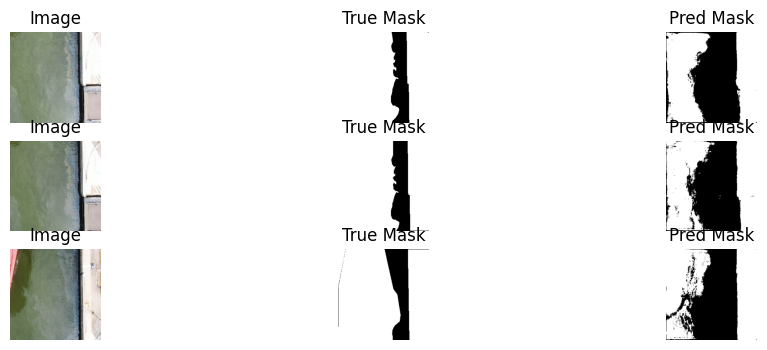

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step


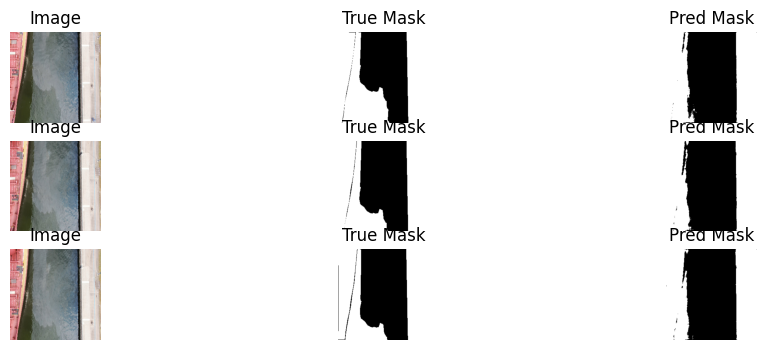

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


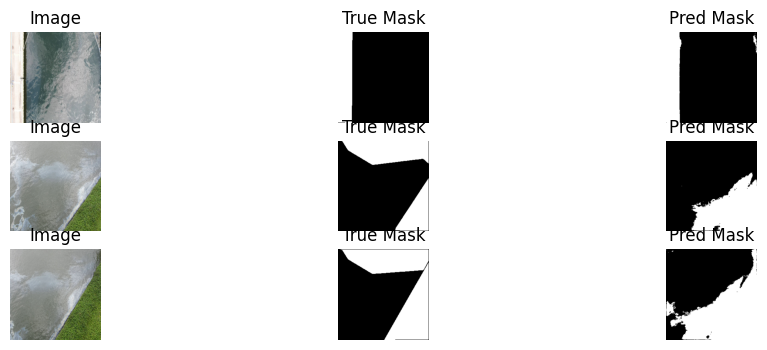

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step


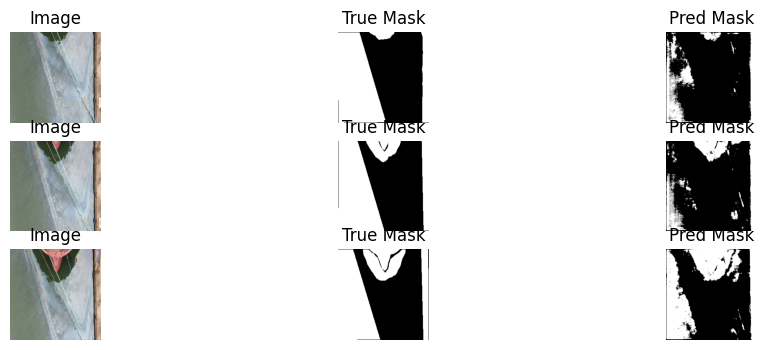

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


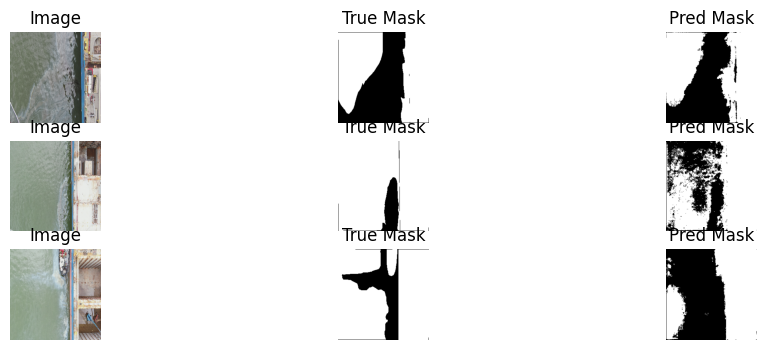

In [ ]:
#Inference on new images
for images, masks in val_ds.take(5):
    preds = seg_model.predict(images)
    plt.figure(figsize=(12,4))
    for i in range(3):
        plt.subplot(3,3,i*3+1); plt.imshow(unnormalize(images[i]).numpy()); plt.title("Image"); plt.axis("off")
        plt.subplot(3,3,i*3+2); plt.imshow(masks[i].numpy().squeeze(), cmap='gray'); plt.title("True Mask"); plt.axis("off")
        plt.subplot(3,3,i*3+3); plt.imshow((preds[i].squeeze()>0.5), cmap='gray'); plt.title("Pred Mask"); plt.axis("off")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

/tmp/ipython-input-1403592478.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([dice_scores, iou_scores], labels=["Dice", "IoU"])


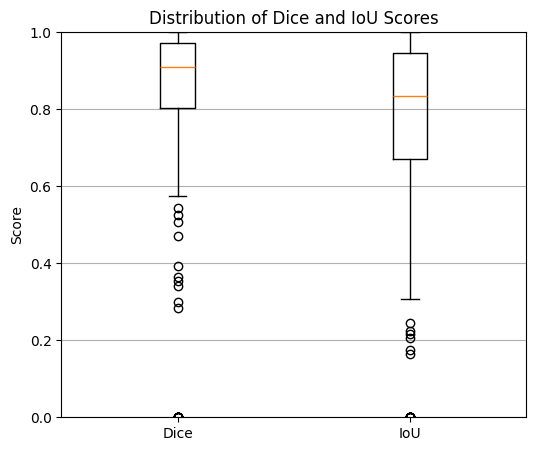

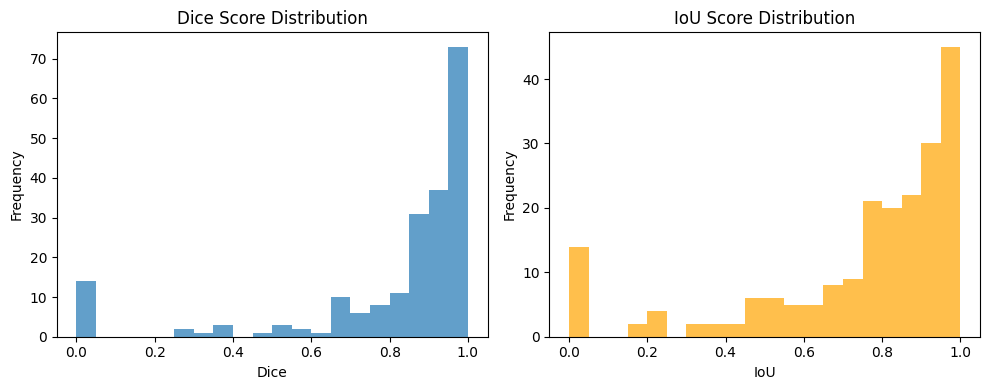

Mean Dice: 0.814 ± 0.263
Mean IoU : 0.746 ± 0.275


In [ ]:
# --- Collect per-image Dice & IoU ---
dice_scores = []
iou_scores  = []

threshold = 0.5  # can adjust if you found better

for batch in val_ds:
    images, masks = batch
    preds = seg_model.predict(images)

    preds_bin = (preds > threshold).astype(np.uint8)

    for i in range(len(images)):
        y_true = masks[i].numpy().astype(np.uint8).squeeze()
        y_pred = preds_bin[i, ..., 0]

        dice_scores.append(dice_coef(y_true, y_pred))
        iou_scores.append(iou_score(y_true, y_pred))

dice_scores = np.array(dice_scores)
iou_scores = np.array(iou_scores)

# --- Boxplot ---
plt.figure(figsize=(6,5))
plt.boxplot([dice_scores, iou_scores], labels=["Dice", "IoU"])
plt.title("Distribution of Dice and IoU Scores")
plt.ylabel("Score")
plt.ylim(0,1)
plt.grid(True, axis='y')
plt.show()

# --- Histogram ---
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(dice_scores, bins=20, alpha=0.7)
plt.title("Dice Score Distribution")
plt.xlabel("Dice")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(iou_scores, bins=20, alpha=0.7, color="orange")
plt.title("IoU Score Distribution")
plt.xlabel("IoU")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Print summary
print(f"Mean Dice: {np.mean(dice_scores):.3f} ± {np.std(dice_scores):.3f}")
print(f"Mean IoU : {np.mean(iou_scores):.3f} ± {np.std(iou_scores):.3f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 

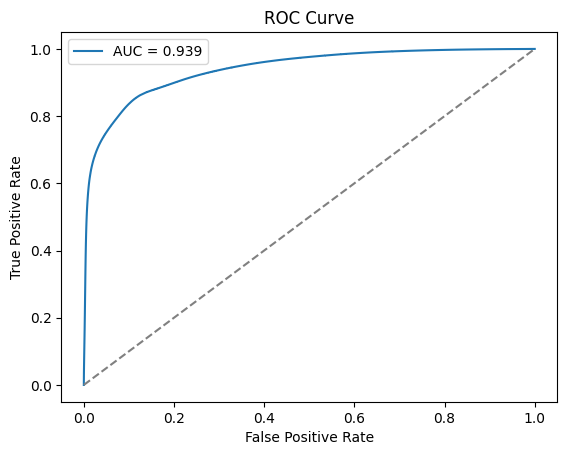

In [ ]:
from sklearn.metrics import roc_curve, auc

# Collect ground truth and predictions
y_true = []
y_pred = []
for images, masks in val_ds:
    preds = seg_model.predict(images)
    y_true.append(masks.numpy().flatten())
    y_pred.append(preds.flatten())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


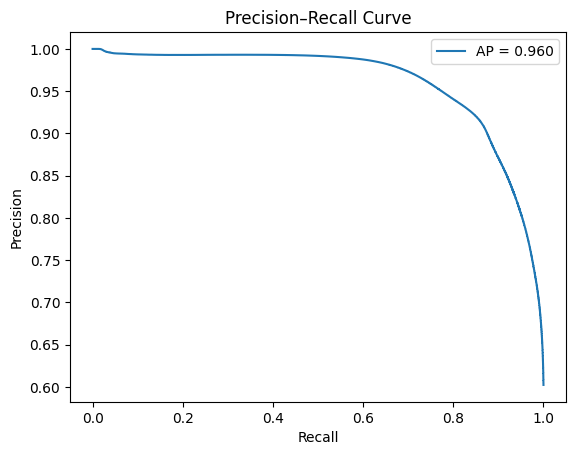

In [ ]:
# Precision–Recall curve
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_true, y_pred)
ap = average_precision_score(y_true, y_pred)

plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.show()

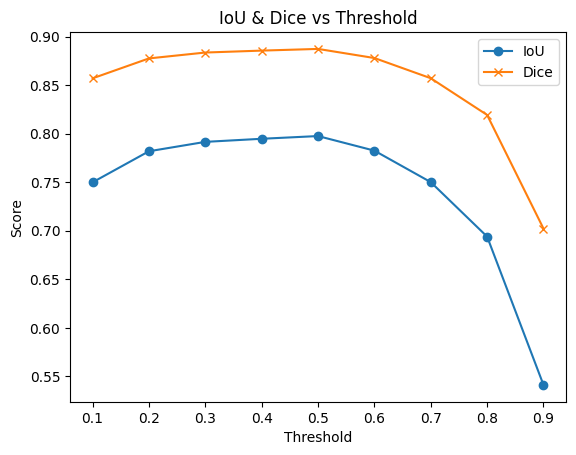

In [ ]:
# IoU / Dice vs Threshold (line graph)
thresholds = np.linspace(0.1, 0.9, 9)
ious, dices = [], []

for t in thresholds:
    y_bin = (y_pred >= t).astype(int)
    intersection = np.logical_and(y_true, y_bin).sum()
    union = np.logical_or(y_true, y_bin).sum()
    iou = intersection / union
    dice = 2*intersection / (y_true.sum() + y_bin.sum())
    ious.append(iou)
    dices.append(dice)

plt.plot(thresholds, ious, marker="o", label="IoU")
plt.plot(thresholds, dices, marker="x", label="Dice")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("IoU & Dice vs Threshold")
plt.legend()
plt.show()

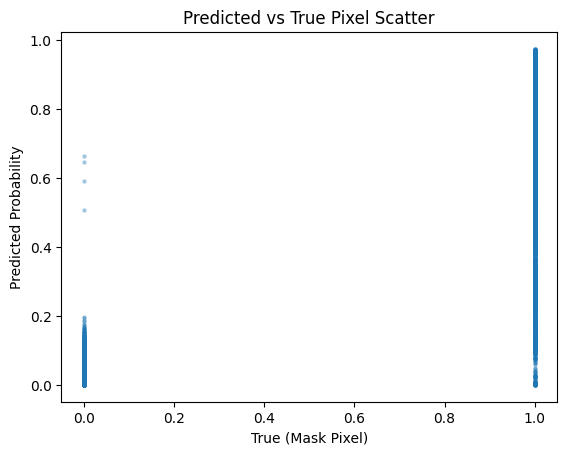

In [ ]:
# Scatter plot of predicted vs true pixel values
plt.scatter(y_true[:5000], y_pred[:5000], alpha=0.3, s=5)
plt.xlabel("True (Mask Pixel)")
plt.ylabel("Predicted Probability")
plt.title("Predicted vs True Pixel Scatter")
plt.show()

In [ ]:
# Take one batch from validation dataset
sample_batch = next(iter(val_ds))
val_images, val_masks = sample_batch

i = 0
image = val_images[i]
mask  = val_masks[i]

pred = seg_model.predict(image[np.newaxis, ...])[0, ..., 0]


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


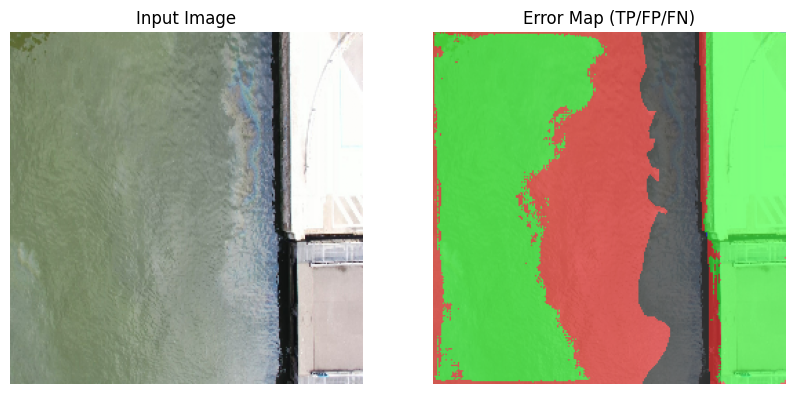

In [ ]:
mask = np.squeeze(mask)   # from (H, W, 1) → (H, W)
threshold = 0.5
pred_bin = (pred > threshold).astype(np.uint8)

TP = np.logical_and(pred_bin == 1, mask == 1)
FP = np.logical_and(pred_bin == 1, mask == 0)
FN = np.logical_and(pred_bin == 0, mask == 1)

error_map = np.zeros((*mask.shape, 3))
error_map[TP] = [0, 1, 0]   # Green = TP
error_map[FP] = [0, 0, 1]   # Blue = FP
error_map[FN] = [1, 0, 0]   # Red = FN

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(image, alpha=0.7)
plt.imshow(error_map, alpha=0.5)
plt.title("Error Map (TP/FP/FN)")
plt.axis("off")
plt.show()


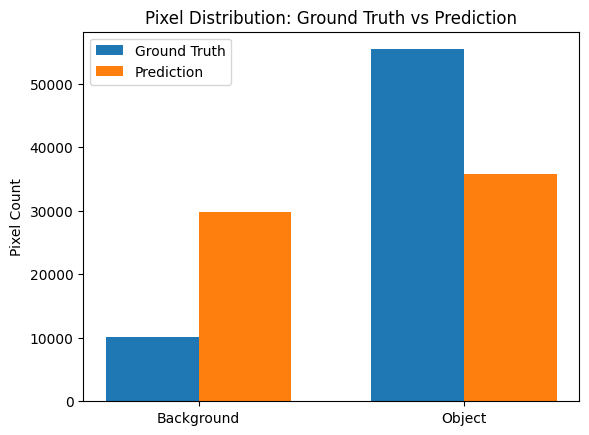

In [ ]:
# Pixel Distribution Histogram
gt_counts = [np.sum(mask == 0), np.sum(mask == 1)]
pred_counts = [np.sum(pred_bin == 0), np.sum(pred_bin == 1)]

labels = ["Background", "Object"]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, gt_counts, width, label="Ground Truth")
ax.bar(x + width/2, pred_counts, width, label="Prediction")

ax.set_ylabel("Pixel Count")
ax.set_title("Pixel Distribution: Ground Truth vs Prediction")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.show()


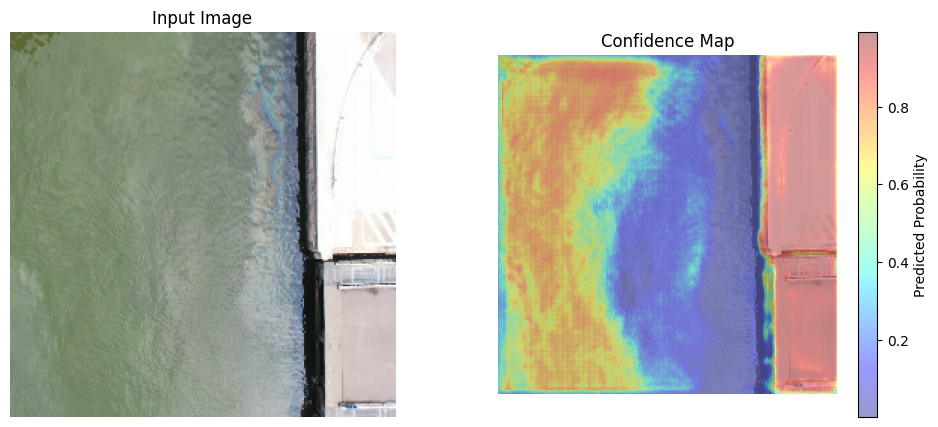

In [ ]:
# Confidence Map

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(image, alpha=0.6)
plt.imshow(pred, cmap="jet", alpha=0.4)
plt.colorbar(label="Predicted Probability")
plt.title("Confidence Map")
plt.axis("off")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


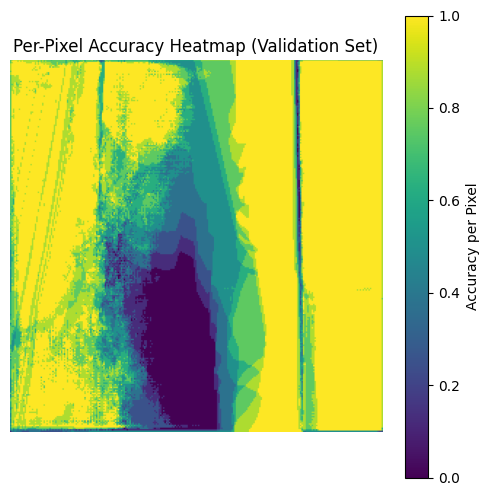

In [ ]:
n, h, w, _ = val_images.shape
acc_map = np.zeros((h, w))

for i in range(n):
    pred = seg_model.predict(val_images[i:i+1])[0, ..., 0]
    pred_bin = (pred > 0.5).astype(np.uint8)

    # Convert mask to numpy + squeeze channel
    mask = val_masks[i].numpy().squeeze()

    acc_map += (pred_bin == mask).astype(np.float32)

acc_map /= n

plt.figure(figsize=(6,6))
plt.imshow(acc_map, cmap="viridis")
plt.colorbar(label="Accuracy per Pixel")
plt.title("Per-Pixel Accuracy Heatmap (Validation Set)")
plt.axis("off")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


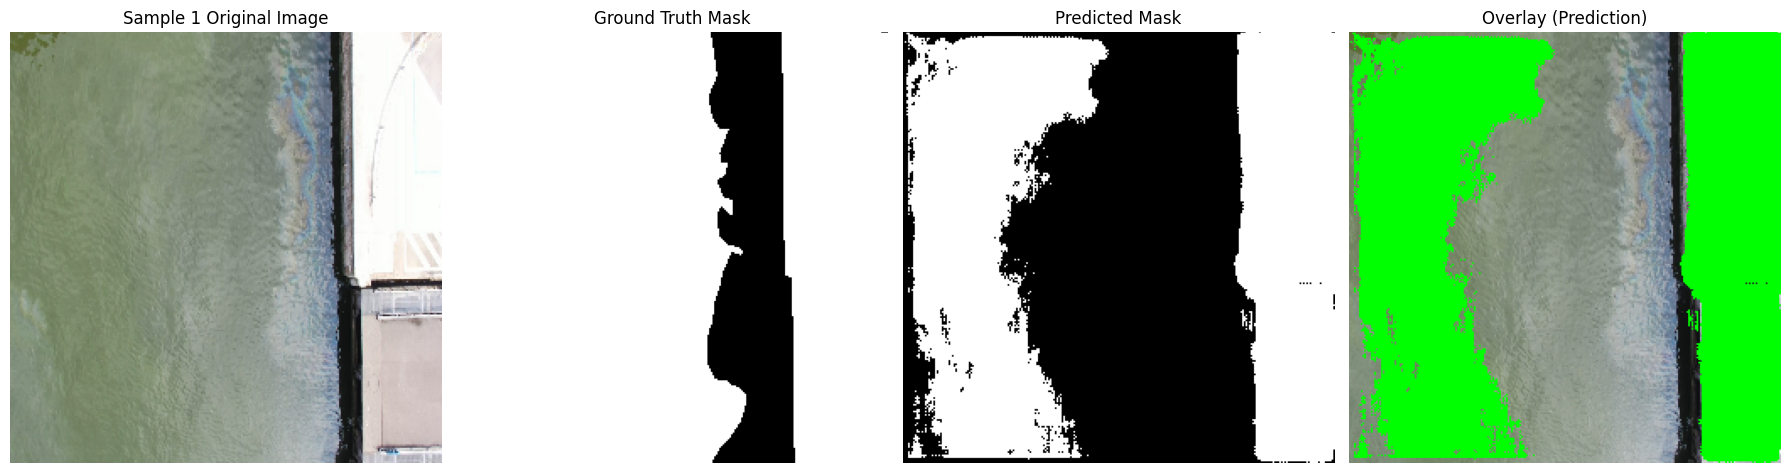

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_sample(image, mask, pred=None, threshold=0.5, title_prefix=""):
    """
    Displays an image with its ground truth and predicted segmentation mask.

    Args:
        image (np.array): Original image (H, W, 3)
        mask (np.array): Ground truth mask (H, W)
        pred (np.array): Predicted probability map (H, W), optional
        threshold (float): Threshold for binarizing prediction
        title_prefix (str): Optional prefix for titles (e.g. "Sample 1")
    """
    fig, axs = plt.subplots(1, 4 if pred is not None else 2, figsize=(18, 5))

    # Original image
    axs[0].imshow(image)
    axs[0].set_title(f"{title_prefix} Original Image")
    axs[0].axis("off")

    # Ground truth mask
    axs[1].imshow(mask, cmap="gray")
    axs[1].set_title("Ground Truth Mask")
    axs[1].axis("off")

    if pred is not None:
        pred_bin = (pred > threshold).astype(np.uint8)

        # Predicted mask
        axs[2].imshow(pred_bin, cmap="gray")
        axs[2].set_title("Predicted Mask")
        axs[2].axis("off")

        # Overlay
        overlay = image.copy()
        overlay[pred_bin == 1] = [0, 1, 0]  # Green overlay
        axs[3].imshow(overlay)
        axs[3].set_title("Overlay (Prediction)")
        axs[3].axis("off")

    plt.tight_layout()
    plt.show()
# Pick one validation sample
for images, masks in val_ds.take(1):
    img = images[0].numpy()
    gt = masks[0].numpy().squeeze()

    pred = best_model.predict(img[np.newaxis, ...])[0, ..., 0]

    visualize_sample(img, gt, pred, threshold=0.6, title_prefix="Sample 1")
